# 06 · Waves, caches and the bill

*The previous posts took the engine apart. This one puts it back together: what a request does, phase by phase, how later fields get to see earlier answers, why the first field goes first, and what all of it costs against letting the model write the JSON itself.*

> **TL;DR**
> - A warm 28-field request is four forward passes: the input, the first field, its answer line and one batched round. The head cache removes the largest cost of a cold request, as long as it is big enough for the schemas you serve: a least-recently-used cache one entry too small for a rotation of schemas gets no hits at all.
> - `depends_on` and first-field anchoring work the same way: answers are written into the prompt as JSON lines and the next wave reads them. Each extra wave costs two forward passes. Anchoring fixed a small model's reading of a double-billing ticket, and it is the schema's own lines that help, not just any line.
> - On `qwen2.5-1.5b`, `pcd` is about 4× faster (3.6–4.6× in this run) than token-by-token JSON on the three 28-field presets, and its output always matches the schema, which the autoregressive output never did.
> - It loses on the 255-label preset: four fields, a 4,600-token prompt, and several sequential rounds cost more than writing 47 tokens.

In [1]:
from nbutils import *
import sys
import time
from dataclasses import asdict

import numpy as np
import matplotlib.pyplot as plt

from pcd import DecodeOptions, Engine, PromptFormat, Schema
from pcd.baseline import generate_json, lenient_values
from pcd.compiler import encode_after
from pcd.decoding import decode_fields
from pcd.engine import _plan_waves

sys.path.insert(0, str(ROOT / "tests"))
from test_real_models import TICKET, SCHEMA       # the double-billing ticket of the real-model tests

environment()
engine = Engine(load())          # qwen2.5-1.5b, 4-bit MLX
backend, tok = engine.backend, engine.tokenizer
presets = {name: load_preset(name) for name in PRESET_NAMES}
ticket, triage = presets["support_triage"]["context"], presets["support_triage"]["schema"]

Apple M1 Pro, 16 GB | macOS 15.1.1 | Python 3.13.5 | pcd 0.1.0, mlx 0.32.2, mlx-lm 0.31.3, torch 2.14.0, transformers 5.17.0


## 1. One request, phase by phase

Posts [02](02_schemas_and_prompts.ipynb) to [05](05_backends.ipynb) each covered one stage. `Engine._extract` strings them together. After the prompt is prefilled (head from the cache, then the input), the whole decision procedure is this loop over waves:

In [2]:
show_source("engine.py", "results: dict[str, Any] = {}", "results.update(res)")

# src/pcd/engine.py
154          results: dict[str, Any] = {}
155          written = cs.prompt.tail  # text the current prefix ends with
156          waves = _plan_waves(cs.schema.waves, opts.anchor_first)
157          for w, names in enumerate(waves):
158              if w > 0:
159                  t = time.perf_counter()
160                  new_lines = cs.answer_text({n: results[n].value for n in waves[w - 1]})
161                  ext = encode_after(tok, written, new_lines, "answers of the previous wave")
162                  prefix = self.backend.prefill(ext, parent=prefix)
163                  written += new_lines
164                  stats.prefill_ms += (time.perf_counter() - t) * 1e3
165              t = time.perf_counter()
166              res, rounds, rows = decode_fields(self.backend, prefix, [cs.fields[n] for n in names], opts, wave=w)
167              stats.decode_ms += (time.perf_counter() - t) * 1e3
168              stats.decode_rounds += rounds
169              stats.ro

Each wave is decided in batched scoring rounds (`decode_fields`, post [04](04_decoding.ipynb)). Between waves, the answers so far are written into the prompt as JSON lines and prefilled on top of it. Sections 3 and 4 are about why there is more than one wave.

To see where the time goes, we record when every backend call starts and ends. This is the call log of post [05](05_backends.ipynb) §1 with a clock added:

In [3]:
class Timeline:
    """Record the start, end and size of every prefill / score call made inside the block."""

    def __init__(self, backend):
        self.backend, self.events = backend, []

    def __enter__(self):
        b = self.backend

        def wrap(name):
            method = getattr(type(b), name)

            def call(*args, **kwargs):
                t0, n0 = time.perf_counter(), b.forward_passes
                result = method(b, *args, **kwargs)
                if name == "prefill":
                    parent = kwargs.get("parent", args[1] if len(args) > 1 else None)
                    size, detail = len(args[0]), parent is None
                else:
                    size, detail = len(args[1]), max(len(r) for r in args[1])
                self.events.append((name, t0 - self.t0, time.perf_counter() - self.t0, b.forward_passes - n0, size, detail))
                return result

            return call

        b.prefill, b.score = wrap("prefill"), wrap("score")
        self.t0 = time.perf_counter()
        return self

    def __exit__(self, *exc):
        self.end = time.perf_counter() - self.t0
        del self.backend.prefill, self.backend.score

    def phases(self):
        """(phase, start, end) in seconds, named after what the engine uses each call for."""
        out, context_done, lines_done = [("compile + tokenize", 0.0, self.events[0][1])], False, False
        for name, start, end, passes, size, detail in self.events:
            if name == "prefill":
                label = "head prefill" if detail else ("answer lines" if context_done else "context prefill")
                lines_done = lines_done or label == "answer lines"
                context_done = context_done or not detail
            else:
                label = "batched round" if lines_done else "first field"
            out.append((label, start, end))
        return out


fresh = Engine(backend)                   # nothing compiled, nothing cached
with Timeline(backend) as tl_cold:
    cold = fresh.extract(ticket, triage)
with Timeline(backend) as tl_warm:
    warm = fresh.extract(ticket, triage)
del fresh

md_table(["`Stats` field", "fresh engine", "second request"],
         [[f"`{k}`", f"{v:.0f}" if isinstance(v, float) else v, f"{asdict(warm.stats)[k]:.0f}" if isinstance(v, float) else asdict(warm.stats)[k]]
          for k, v in asdict(cold.stats).items()])

| `Stats` field | fresh engine | second request |
|---|---|---|
| `total_ms` | 1408 | 663 |
| `tokenize_ms` | 16 | 5 |
| `head_prefill_ms` | 741 | 0 |
| `prefill_ms` | 263 | 266 |
| `decode_ms` | 389 | 392 |
| `prompt_tokens` | 1146 | 1146 |
| `cached_tokens` | 0 | 901 |
| `forward_passes` | 5 | 4 |
| `decode_rounds` | 2 | 2 |
| `rows_scored` | 28 | 28 |
| `waves` | 2 | 2 |

Three things about how `Stats` books its time. `tokenize_ms` on a fresh engine includes compiling the schema, which is cached from then on (post [03](03_compiling_for_the_tokenizer.ipynb) §7). `prefill_ms` counts the input and the answer lines written between waves. `decode_ms` counts every scoring round. The call-by-call view:

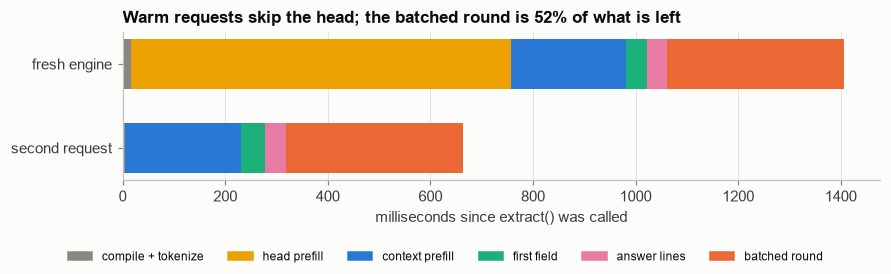

batched round: 27 rows of at most 11 tokens, on a 1155-token prefix
head prefill: 53% of the fresh request; fresh / warm = 2.1x


In [4]:
PHASES = ["compile + tokenize", "head prefill", "context prefill", "first field", "answer lines", "batched round"]
COLORS = dict(zip(PHASES, [MUTED, SERIES[3], SERIES[0], SERIES[2], SERIES[4], SERIES[1]]))

fig, ax = plt.subplots(figsize=(8.2, 2.5))
for y, tl in enumerate([tl_cold, tl_warm]):
    for phase, start, end in tl.phases():
        ax.barh(y, (end - start) * 1e3, left=start * 1e3, height=0.6, color=COLORS[phase])
ax.set_yticks([0, 1], ["fresh engine", "second request"])
ax.invert_yaxis(); ax.grid(axis="y", visible=False)
ax.set_xlabel("milliseconds since extract() was called")
batched = sum(e - s for p, s, e in tl_warm.phases() if p == "batched round")
ax.set_title(f"Warm requests skip the head; the batched round is {batched / tl_warm.end:.0%} of what is left")
fig.legend([plt.Rectangle((0, 0), 1, 1, color=COLORS[p]) for p in PHASES], PHASES, loc="lower center", ncol=6, fontsize=8)
plt.tight_layout(rect=(0, 0.1, 1, 1)); plt.show()

last = tl_warm.events[-1]
line_tokens = sum(ev[4] for ev, ph in zip(tl_warm.events, tl_warm.phases()[1:]) if ph[0] == "answer lines")
print(f"batched round: {last[4]} rows of at most {last[5]} tokens, on a {warm.stats.prompt_tokens + line_tokens}-token prefix")
print(f"head prefill: {cold.stats.head_prefill_ms / cold.stats.total_ms:.0%} of the fresh request; "
      f"fresh / warm = {cold.stats.total_ms / warm.stats.total_ms:.1f}x")

On a fresh engine the head prefill is the largest phase. Once it is cached, the largest phase is the batched round, even though its rows are only a few tokens long: every row attends to the whole prompt through its own copy of the KV cache, and copying and reading those copies is what the round spends its time on (post [05](05_backends.ipynb) §2 and §4). The first field and its answer line are the two small slivers in the middle; section 4 explains what they buy.

## 2. Two caches, and how to defeat one

The engine keeps two caches. Compiled schemas are keyed by the schema's fingerprint and the prompt format (post [03](03_compiling_for_the_tokenizer.ipynb) §7); compiling is cheap, so that cache rarely matters. The head cache holds the KV state of each schema's static prompt head (post [02](02_schemas_and_prompts.ipynb) §6), and it matters a lot:

In [5]:
show_source(Engine._head_prefix)

# src/pcd/engine.py
 99      def _head_prefix(self, cs: CompiledSchema) -> tuple[Prefix, float]:
100          """KV state of the static head; returns (prefix, ms spent computing it now)."""
101          cached = self._heads.get(cs.head_ids)
102          if cached is not None:
103              self._heads.move_to_end(cs.head_ids)
104              return cached, 0.0
105          t0 = time.perf_counter()
106          prefix = self.backend.prefill(cs.head_ids)
107          self._heads[cs.head_ids] = prefix
108          while len(self._heads) > self._head_cache_size:
109              self._heads.popitem(last=False)
110          return prefix, (time.perf_counter() - t0) * 1e3


It is a least-recently-used cache of `head_cache_size` entries (four by default), keyed by the head's token ids. Least-recently-used has a well-known failure mode: a cyclic access pattern just larger than the cache evicts every entry right before it is needed. A service that rotates through five schemas is exactly that pattern. We send the same short input with five schemas, in turn, twice:

In [6]:
quick = {
    "sentiment": {"type": "enum", "choices": ["POSITIVE", "NEUTRAL", "NEGATIVE"], "description": "Customer mood"},
    "topic": {"type": "enum", "choices": ["BILLING", "TECHNICAL_ISSUE", "ACCOUNT_ACCESS"], "description": "Main topic"},
    "wants_refund": {"type": "boolean", "description": "Whether the customer asks for money back"},
    "deadline": {"type": "enum", "choices": ["1_HOUR", "12_HOURS", "1_WEEK", "NONE"], "description": "Deadline given"},
    "route_to": {"type": "enum", "choices": ["BILLING_TEAM", "ENGINEERING", "SUPPORT"],
                 "description": "Team that should handle it", "depends_on": ["topic"]},
}                                                   # the schema of examples/quickstart.py
schemas = [p["schema"] for p in presets.values()] + [quick]

rows = []
for size in (4, 5):
    lru = Engine(backend, head_cache_size=size)
    hits = [lru.extract("A short test input.", s).stats.cached_tokens > 0 for _ in range(2) for s in schemas]
    held = sum(h.nbytes for h in lru._heads.values()) / 2**20
    rows.append([size, f"{sum(hits[:5])} of 5", f"{sum(hits[5:])} of 5", f"{held:.0f} MiB"])
    sizes = {len(h): h.nbytes / 2**20 for h in lru._heads.values()}
    del lru
md_table(["`head_cache_size`", "hits, first pass over the 5 schemas", "hits, second pass", "KV memory held by the cache"], rows)
print("each head's KV state:", ", ".join(f"{n} tokens {mib:.1f} MiB" for n, mib in sorted(sizes.items())))

| `head_cache_size` | hits, first pass over the 5 schemas | hits, second pass | KV memory held by the cache |
|---|---|---|---|
| 4 | 0 of 5 | 0 of 5 | 175 MiB |
| 5 | 0 of 5 | 5 of 5 | 200 MiB |

each head's KV state: 178 tokens 4.9 MiB, 831 tokens 22.7 MiB, 901 tokens 24.6 MiB, 927 tokens 25.3 MiB, 4461 tokens 122.0 MiB


With four entries, the second pass over five schemas gets no hits at all, and every request pays for its head again. One more entry turns every request of the second pass into a hit. The cost of a bigger cache is memory: each entry holds the full KV state of a head, from about 5 MiB for the five-field quickstart schema to over 120 MiB for the 255-label catalog. Size the cache to the number of schemas you serve.

Because the key is the head's token ids, two schemas whose catalogs render identically share an entry. We will use that in the next section: a schema with `depends_on` and the same schema without it have the same head.

## 3. Waves: letting some fields see others

Fields decided in the same batched round do not see each other's answers (post [01](01_why_parallel_decoding.ipynb) §4). `depends_on` is the way out: a field is decided in a later wave, after the answers it depends on have been written into the prompt. The quickstart schema above makes `route_to` depend on `topic`:

In [7]:
S = Schema.coerce(quick)
print("waves from depends_on      :", S.waves)
print("with the first field first :", _plan_waves(S.waves, anchor_first=True))
flat = {k: {a: b for a, b in f.items() if a != "depends_on"} for k, f in quick.items()}
print("same head without depends_on:", engine.compile(quick).head_ids == engine.compile(flat).head_ids)

waves from depends_on      : [['sentiment', 'topic', 'wants_refund', 'deadline'], ['route_to']]
with the first field first : [['sentiment'], ['topic', 'wants_refund', 'deadline'], ['route_to']]
same head without depends_on: True


`Schema.waves` comes from the dependency graph; the engine then splits off the first field (section 4), so this schema is decided in three waves. We use a ticket where the topic is not obvious: it is about invoices, but the problem is a crashing page.

In [8]:
mixed = ("Since your update I can't download my invoices, the page crashes. "
         "I need them for my accountant this week.")
cs = engine.compile(quick)
out = engine.extract(mixed, quick)
print(out.values)
print("waves:", {k: f.wave for k, f in out.fields.items()})

plan = _plan_waves(cs.schema.waves, True)
written = cs.prompt.tail + "".join(cs.answer_text({n: out.values[n] for n in wave}) for wave in plan[:-1])
print("\nwhat the route_to row continues from:\n" + written + tok.decode(list(cs.fields["route_to"].prefix)))

{'sentiment': 'NEGATIVE', 'topic': 'TECHNICAL_ISSUE', 'wants_refund': False, 'deadline': '1_WEEK', 'route_to': 'ENGINEERING'}
waves: {'sentiment': 0, 'topic': 1, 'wants_refund': 1, 'deadline': 1, 'route_to': 2}

what the route_to row continues from:
<|im_end|>
<|im_start|>assistant
{
  "sentiment": "NEGATIVE",
  "topic": "TECHNICAL_ISSUE",
  "wants_refund": false,
  "deadline": "1_WEEK",
  "route_to": "


`route_to` is decided with `"topic": "TECHNICAL_ISSUE"` in front of it, exactly as if the model had written those lines itself. Does it actually read them? We rebuild the engine's KV state with each possible topic written in, and decide `route_to` on each:

In [9]:
def prefix_after(eng, cs, context, *lines):
    """The KV state the engine decides against: head, then input, then each item written as JSON
    lines (a dict of answers, via `answer_text`) or as raw text (a str)."""
    b, t = eng.backend, eng.tokenizer
    ids = t.encode(cs.prompt.render(context.strip()))
    p = b.prefill(ids[len(cs.head_ids):], parent=b.prefill(cs.head_ids))
    written = cs.prompt.tail
    for item in lines:
        text = cs.answer_text(item) if isinstance(item, dict) else item
        p = b.prefill(encode_after(t, written, text), parent=p)
        written += text
    return p


def route_to(prefix):
    res, _, _ = decode_fields(backend, prefix, [cs.fields["route_to"]], engine.decode, wave=2)
    return dict(res["route_to"].top)


first = {"sentiment": out.values["sentiment"]}
rows = []
for topic in cs.schema["topic"].choices:
    second = {n: (topic if n == "topic" else out.values[n]) for n in plan[1]}
    probs = route_to(prefix_after(engine, cs, mixed, first, second))
    rows.append([f'`"topic": "{topic}"` written', *(f"{probs[l]:.2f}" for l in cs.schema["route_to"].choices)])
no_dep = engine.extract(mixed, flat).fields["route_to"]
rows.append(["no `depends_on` (same wave as `topic`)", *(f"{dict(no_dep.top)[l]:.2f}" for l in cs.schema["route_to"].choices)])
md_table(["what `route_to` sees", *(f"P({l})" for l in cs.schema["route_to"].choices)], rows)

| what `route_to` sees | P(BILLING_TEAM) | P(ENGINEERING) | P(SUPPORT) |
|---|---|---|---|
| `"topic": "BILLING"` written | 0.38 | 0.32 | 0.29 |
| `"topic": "TECHNICAL_ISSUE"` written | 0.14 | 0.65 | 0.21 |
| `"topic": "ACCOUNT_ACCESS"` written | 0.17 | 0.42 | 0.41 |
| no `depends_on` (same wave as `topic`) | 0.20 | 0.45 | 0.35 |

It does. With `BILLING` written, `BILLING_TEAM` becomes the most likely team; with `TECHNICAL_ISSUE`, `ENGINEERING` is, and more decisively than without `depends_on`, when `route_to` has to guess the topic on its own.

Reading is not obeying, though. `depends_on` gives the model information; it does not add a rule. On the quickstart's own billing ticket, the topic comes out as `BILLING` and the route still does not follow:

In [10]:
billing = ("I was billed twice for my March invoice. Please refund the duplicate charge "
           "within 12 hours or I'm cancelling. Really disappointed.")
b_out = engine.extract(billing, quick)
print(f"topic {b_out.values['topic']}  →  route_to {b_out.values['route_to']}   "
      + ", ".join(f"{l} {p:.2f}" for l, p in b_out.fields["route_to"].top))

topic BILLING  →  route_to SUPPORT   SUPPORT 0.56, ENGINEERING 0.27, BILLING_TEAM 0.17


A 1.5B model does not map "billing" to "billing team" with much conviction. If two fields must be consistent, derive one from the other in code; `depends_on` is for fields that should be *informed* by another.

Every wave costs two forward passes, one to prefill the answer lines and one to score, and it adds a sequential step:

In [11]:
dep_ms, dep = timed(lambda: engine.extract(mixed, quick))
flat_ms, fl = timed(lambda: engine.extract(mixed, flat))
print(f"with depends_on: {dep.stats.waves} waves, {dep.stats.forward_passes} forward passes")
print(f"without        : {fl.stats.waves} waves, {fl.stats.forward_passes} forward passes   ({dep_ms / flat_ms:.2f}x the latency with depends_on)")

with depends_on: 3 waves, 6 forward passes
without        : 2 waves, 4 forward passes   (1.50x the latency with depends_on)


## 4. Why the first field goes first

Section 3 showed a wave that nobody asked for: the schema's first field is decided on its own, its answer is written into the prompt, and only then is everything else decided. This is `DecodeOptions.anchor_first`, on by default, and it came out of a failure.

Think about what the batched round looks like without it. Every row is appended straight after the `{` that opens the object, so every field is asked as if it were *the first key of the object*. For the schema's actual first field, that is true. For every other field, it is a situation the model never sees when it writes JSON itself, and small models answer some keys worse there.

The clearest case we found is Qwen3-0.6B on the double-billing ticket from the real-model tests:

In [12]:
engine = backend = tok = None           # release qwen2.5 before loading the next model
unload()
q3 = Engine(load("qwen3-0.6b"))
print(TICKET, "\n")
for anchor in (False, True):
    r = q3.extract(TICKET, SCHEMA, anchor_first=anchor)
    top = ", ".join(f"{l} {p:.3f}" for l, p in r.fields["topic"].top[:3])
    print(f"anchor_first={anchor!s:5}  topic: {top}   route_to: {r.values['route_to']}   ({r.stats.forward_passes} forward passes)")
ar = lenient_values(SCHEMA, generate_json(q3, TICKET, SCHEMA).values)
print(f"token by token              topic: {ar['topic']}   route_to: {ar['route_to']}")

Subject: Charged twice for my March invoice!!

Hi, I was billed twice for my March invoice ($49 each). I am really annoyed, this is the third time I write about it. Please refund the duplicate charge within 12 hours or I will cancel. I'm on the Premium plan.
-- Dana 



anchor_first=False  topic: FEATURE_REQUEST 0.662, TECHNICAL_ISSUE 0.313, BILLING 0.026   route_to: SALES   (5 forward passes)


anchor_first=True   topic: BILLING 1.000, FEATURE_REQUEST 0.000, TECHNICAL_ISSUE 0.000   route_to: BILLING_TEAM   (6 forward passes)


token by token              topic: BILLING   route_to: BILLING_TEAM


Without the anchor, the model calls a double-billing complaint a feature request, and the dependent `route_to` follows it to `SALES`. With `"sentiment": "NEGATIVE",` written first, `topic` is `BILLING` with near certainty, which is also what the model writes when it generates the whole object itself.

What exactly fixes it? `pcd`'s README and the `anchor_first` docstring say that *any* JSON line in front does. We tested that, deciding `topic` alone after different lines:

In [13]:
cs3 = q3.compile(SCHEMA)
lines = {
    "nothing (right after `{`)": None,
    "the schema's first key, right answer": '  "sentiment": "NEGATIVE",\n',
    "the schema's first key, wrong answer": '  "sentiment": "POSITIVE",\n',
    "another schema key": '  "plan": "PREMIUM",\n',
    "a boolean schema key": '  "is_spam": false,\n',
    "a foreign key: customer": '  "customer": "Dana",\n',
    "a foreign key: ticket_id": '  "ticket_id": "A-1042",\n',
    "a foreign key: language": '  "language": "en",\n',
}
rows = []
for label, line in lines.items():
    p = prefix_after(q3, cs3, TICKET, *([line] if line else []))
    res, _, _ = decode_fields(q3.backend, p, [cs3.fields["topic"]], q3.decode, wave=1)
    r = res["topic"]
    rows.append([label, f"`{line.strip()}`" if line else "", r.value, f"{dict(r.top)['BILLING']:.3f}"])
    del p
md_table(["line before the `topic` row", "text", "topic", "P(BILLING)"], rows)
q3 = cs3 = None
unload()

| line before the `topic` row | text | topic | P(BILLING) |
|---|---|---|---|
| nothing (right after `{`) |  | FEATURE_REQUEST | 0.025 |
| the schema's first key, right answer | `"sentiment": "NEGATIVE",` | BILLING | 1.000 |
| the schema's first key, wrong answer | `"sentiment": "POSITIVE",` | BILLING | 0.999 |
| another schema key | `"plan": "PREMIUM",` | BILLING | 0.958 |
| a boolean schema key | `"is_spam": false,` | BILLING | 0.827 |
| a foreign key: customer | `"customer": "Dana",` | BILLING | 0.689 |
| a foreign key: ticket_id | `"ticket_id": "A-1042",` | TECHNICAL_ISSUE | 0.254 |
| a foreign key: language | `"language": "en",` | TECHNICAL_ISSUE | 0.035 |

Not any line. Every line that looks like part of this schema's answer makes `BILLING` the winner, from 0.83 for a boolean key to near certainty for the schema's first key, even when the answer in it is wrong. Lines with foreign keys are hit and miss: a customer name helps, a ticket id or a language code leaves `topic` wrong. The anchor writes the most natural line there is: the catalog's first key, answered by the model itself.

It is also a risk. The first answer is written into the prompt before 27 other fields are decided, and when it is wrong, the others can follow it: post [04](04_decoding.ipynb) §3 shows a wrong first boolean flipping 24 fields. So the question is empirical. Back on `qwen2.5-1.5b`, we measure agreement with the model's own token-by-token answer on every preset, with the anchor on and off, and what the extra round costs:

In [14]:
engine = Engine(load())
backend, tok = engine.backend, engine.tokenizer
bench = {}
for name, p in presets.items():
    ctx, sch = p["context"], p["schema"]
    row = {"arv": lenient_values(sch, generate_json(engine, ctx, sch).values)}
    for anchor in (False, True):
        row[anchor] = timed(lambda: engine.extract(ctx, sch, anchor_first=anchor))
    bench[name] = row


def agreement(name, anchor):
    values, arv = bench[name][anchor][1].values, bench[name]["arv"]
    return sum(arv.get(k) == v for k, v in values.items())


md_table(["preset", "fields", "agreement with AR, anchor off", "anchor on", "latency, on / off"],
         [[name, len(p["schema"]), agreement(name, False), agreement(name, True),
           f"{bench[name][True][0] / bench[name][False][0]:.2f}x"] for name, p in presets.items()])

| preset | fields | agreement with AR, anchor off | anchor on | latency, on / off |
|---|---|---|---|---|
| support_triage | 28 | 14 | 13 | 1.18x |
| fintech_fraud | 28 | 20 | 26 | 1.09x |
| code_security | 28 | 25 | 26 | 1.14x |
| high_cardinality_255 | 4 | 2 | 2 | 1.13x |

On this model the anchor helps a lot on `fintech_fraud`, a little on `code_security`, and costs one field of agreement on `support_triage`; on the 255-label preset it changes nothing. It never costs more than about 20% latency. Agreement with the autoregressive answer is a proxy for faithfulness, not accuracy (post [01](01_why_parallel_decoding.ipynb) §6), and near-ties can flip on fp16 noise alone (post [05](05_backends.ipynb) §3), so a one-field difference can be noise. A big gain on one preset and small effects elsewhere is why the default is on.

## 5. Where the forward passes go

Post [05](05_backends.ipynb) §1 accounts for every call of a triage request. Across the presets, from the warm runs above:

In [15]:
md_table(["preset", "prompt tokens", "from the head cache", "waves", "decode rounds", "rows scored", "forward passes"],
         [[name, s.prompt_tokens, s.cached_tokens, s.waves, s.decode_rounds, s.rows_scored, s.forward_passes]
          for name, s in ((n, bench[n][True][1].stats) for n in presets)])

| preset | prompt tokens | from the head cache | waves | decode rounds | rows scored | forward passes |
|---|---|---|---|---|---|---|
| support_triage | 1146 | 901 | 2 | 2 | 28 | 4 |
| fintech_fraud | 1067 | 831 | 2 | 2 | 28 | 4 |
| code_security | 1172 | 927 | 2 | 2 | 28 | 4 |
| high_cardinality_255 | 4624 | 4461 | 2 | 4 | 15 | 6 |

The three 28-field presets have the same shape: one prefill of the input, one round for the first field, one prefill of its answer line, one batched round for the other 27. The 255-label preset needs more rounds, because its first field is the 255-label one: the trie walk narrows the labels in several sequential rounds before exact scoring settles the last few (post [04](04_decoding.ipynb) §6).

## 6. The benchmark

Now the full comparison. `pcd` with default settings against the same model writing the JSON token by token (`pcd.baseline.generate_json`), same prompt, same cached head, median of three runs after a warm-up:

In [16]:
for name, p in presets.items():
    bench[name]["ar_ms"], bench[name]["ar"] = timed(lambda: generate_json(engine, p["context"], p["schema"]))


def valid(ar):
    if ar.schema_match:
        return "yes"
    parts = [f"{len(ar.missing)} missing"] if ar.missing else []
    parts += [f"{len(ar.invalid)} invalid"] if ar.invalid else []
    return "no (" + ", ".join(parts) + ")"


rows = []
for name, p in presets.items():
    row = bench[name]
    pcd_ms, out = row[True]
    rows.append([name, len(p["schema"]), f"{pcd_ms:.0f} ms", f"{row['ar_ms']:.0f} ms ({row['ar'].new_tokens})",
                 f"{row['ar_ms'] / pcd_ms:.1f}x", out.stats.forward_passes, row["ar"].forward_passes,
                 valid(row["ar"]), f"{agreement(name, True)}/{len(p['schema'])}"])
md_table(["preset", "fields", "pcd", "AR (tokens)", "speed-up", "pcd passes", "AR passes", "AR output schema-valid?", "agreement"], rows)
print("AR invalid values, e.g.:", bench["fintech_fraud"]["ar"].invalid[:3])

| preset | fields | pcd | AR (tokens) | speed-up | pcd passes | AR passes | AR output schema-valid? | agreement |
|---|---|---|---|---|---|---|---|---|
| support_triage | 28 | 671 ms | 2405 ms (271) | 3.6x | 4 | 273 | no (1 missing) | 13/28 |
| fintech_fraud | 28 | 696 ms | 2626 ms (304) | 3.8x | 4 | 306 | no (1 missing, 17 invalid) | 26/28 |
| code_security | 28 | 625 ms | 2861 ms (323) | 4.6x | 4 | 325 | no (14 invalid) | 26/28 |
| high_cardinality_255 | 4 | 867 ms | 660 ms (47) | 0.8x | 6 | 49 | no (1 invalid) | 2/4 |

AR invalid values, e.g.: ["is_fraudulent='true'", "secondary_anomaly='UNUSUAL_VELOCITY'", "requires_human_escalation='true'"]


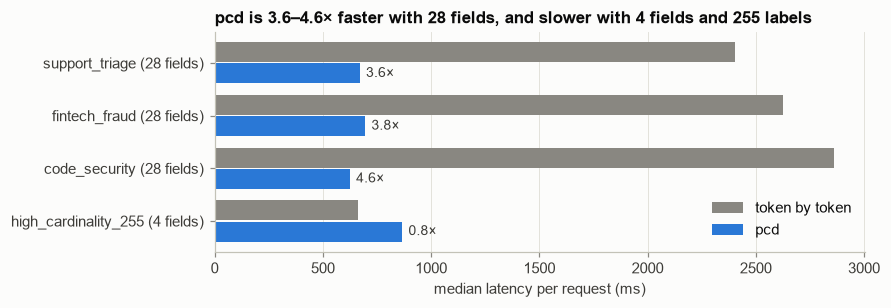

In [17]:
names = list(presets)
speed = [bench[n]["ar_ms"] / bench[n][True][0] for n in names]
fig, ax = plt.subplots(figsize=(8.2, 2.9))
y = np.arange(len(names))
ax.barh(y - 0.2, [bench[n]["ar_ms"] for n in names], height=0.38, color=MUTED, label="token by token")
bars = ax.barh(y + 0.2, [bench[n][True][0] for n in names], height=0.38, color=SERIES[0], label="pcd")
ax.bar_label(bars, [f"{s:.1f}×" for s in speed], padding=4, fontsize=9, color=INK_2)
ax.set_yticks(y, [f"{n} ({len(presets[n]['schema'])} fields)" for n in names])
ax.invert_yaxis(); ax.grid(axis="y", visible=False)
ax.set_xlabel("median latency per request (ms)")
fast = [s for n, s in zip(names, speed) if len(presets[n]["schema"]) == 28]
ax.set_title(f"pcd is {min(fast):.1f}–{max(fast):.1f}× faster with 28 fields, and slower with 4 fields and 255 labels")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

On the 28-field presets, `pcd` is 3.6 to 4.6 times faster, and every one of its outputs is valid by construction. None of the autoregressive outputs match their schema. Two stop before the last key; two write booleans as strings (`"true"`), which a strict consumer rejects, and one of them also borrows another field's label; and the customs answer is a label that does not exist. We map string booleans to real ones before counting agreement (`lenient_values`), so the agreement column does not punish the baseline for formatting.

Agreement is high on `fintech_fraud` and `code_security` and about half on `support_triage`, the ticket post [01](01_why_parallel_decoding.ipynb) §6 looked at field by field: some of its disagreements are near-ties, and others are fields where the autoregressive run drifted. The 255-label preset is the exception to the speed-up, and section 8 takes it apart.

## 7. Scaling with the number of fields

Token-by-token generation pays for every token of every field. `pcd` pays for rows in a batch. We time both on the first *k* fields of the triage schema:

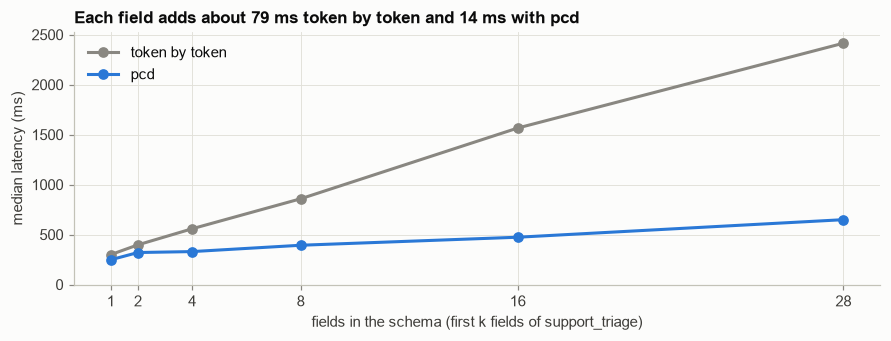

| fields | pcd | AR | speed-up | AR tokens | pcd prompt tokens | pcd passes |
|---|---|---|---|---|---|---|
| 1 | 248 ms | 299 ms | 1.2x | 11 | 325 | 2 |
| 2 | 320 ms | 397 ms | 1.2x | 24 | 372 | 4 |
| 4 | 329 ms | 558 ms | 1.7x | 43 | 458 | 4 |
| 8 | 393 ms | 858 ms | 2.2x | 82 | 554 | 4 |
| 16 | 473 ms | 1566 ms | 3.3x | 164 | 798 | 4 |
| 28 | 649 ms | 2414 ms | 3.7x | 271 | 1146 | 4 |

In [18]:
ks = [1, 2, 4, 8, 16, 28]
scale = []
for k in ks:
    sch = dict(list(triage.items())[:k])
    pcd_ms, out = timed(lambda: engine.extract(ticket, sch))
    ar_ms, ar = timed(lambda: generate_json(engine, ticket, sch))
    scale.append((k, pcd_ms, ar_ms, ar.new_tokens, out.stats.prompt_tokens, out.stats.forward_passes))
ks_, pcd_ms_, ar_ms_ = (np.array(c) for c in list(zip(*scale))[:3])
pcd_slope, ar_slope = np.polyfit(ks_, pcd_ms_, 1)[0], np.polyfit(ks_, ar_ms_, 1)[0]

fig, ax = plt.subplots(figsize=(8.2, 3.2))
ax.plot(ks_, ar_ms_, "o-", color=MUTED, label="token by token")
ax.plot(ks_, pcd_ms_, "o-", color=SERIES[0], label="pcd")
ax.set_xticks(ks_)
ax.set_xlabel("fields in the schema (first k fields of support_triage)")
ax.set_ylabel("median latency (ms)")
ax.set_ylim(0, None)
ax.set_title(f"Each field adds about {ar_slope:.0f} ms token by token and {pcd_slope:.0f} ms with pcd")
ax.legend()
plt.tight_layout(); plt.show()
md_table(["fields", "pcd", "AR", "speed-up", "AR tokens", "pcd prompt tokens", "pcd passes"],
         [[k, f"{p:.0f} ms", f"{a:.0f} ms", f"{a / p:.1f}x", n, t, f] for k, p, a, n, t, f in scale])

The autoregressive cost is a straight line: about ten tokens per field, each a sequential forward pass. `pcd` grows too, but more slowly. Every field adds a row to the batched round and a line to the catalog, so the rows get more numerous and the prompt they attend to gets longer. With a single field `pcd` is barely faster than writing one short line; the advantage grows with every field.

## 8. When `pcd` loses

The 255-label preset has four fields, one of which is a customs category with 255 labels. Two things make it expensive for `pcd`, and neither is the number of fields:

In [19]:
cust = presets["high_cardinality_255"]
cust_ms, c_out = bench["high_cardinality_255"][True]
tri_ms, t_out = bench["support_triage"][True]
c_ar = bench["high_cardinality_255"]["ar"]
print(f"prompt tokens: {c_out.stats.prompt_tokens} vs {t_out.stats.prompt_tokens} for triage ({c_out.stats.prompt_tokens / t_out.stats.prompt_tokens:.1f}x)")
engine.extract(cust["context"], cust["schema"])        # the scaling runs above evicted its head; cache it again
with Timeline(backend) as tl:
    engine.extract(cust["context"], cust["schema"])
md_table(["call", "phase", "size", "forward passes", "ms"],
         [[f"`{name}`", phase, f"{size} row{'s' * (size > 1)} of up to {detail} tokens" if name == "score" else f"{size} tokens", passes, f"{(end - start) * 1e3:.0f}"]
          for (name, start, end, passes, size, detail), (phase, _, _) in zip(tl.events, tl.phases()[1:])])
print(f"pcd: prefill {c_out.stats.prefill_ms:.0f} ms, decode {c_out.stats.decode_ms:.0f} ms in {c_out.stats.decode_rounds} rounds | "
      f"AR: prefill {c_ar.prefill_ms:.0f} ms, generation {c_ar.decode_ms:.0f} ms for {c_ar.new_tokens} tokens")

prompt tokens: 4624 vs 1146 for triage (4.0x)


| call | phase | size | forward passes | ms |
|---|---|---|---|---|
| `prefill` | context prefill | 163 tokens | 1 | 213 |
| `score` | first field | 1 row of up to 9 tokens | 1 | 61 |
| `score` | first field | 1 row of up to 10 tokens | 1 | 62 |
| `score` | first field | 10 rows of up to 26 tokens | 1 | 373 |
| `prefill` | answer lines | 22 tokens | 1 | 62 |
| `score` | batched round | 3 rows of up to 8 tokens | 1 | 93 |

pcd: prefill 273 ms, decode 588 ms in 4 rounds | AR: prefill 218 ms, generation 429 ms for 47 tokens


First, the catalog. Listing 255 labels makes the prompt four times as long as triage's, and every row in a batched round attends to all of it through its own KV copy (post [05](05_backends.ipynb) §4 puts that at 126 MiB per row). Second, the rounds. The first field is the 255-label one, so the anchor is a trie walk: two single-row steps down the trie, then exact scoring of the ten labels left, each in its own row with its own copy of the prompt. That last round is the most expensive call of the request. Only then is the answer line written and the other three fields decided in one small round.

The autoregressive baseline, meanwhile, writes 47 tokens. Four short fields is the worst case for `pcd`: there is little scaffolding to skip, and a lot of prompt to copy.

Can we shrink the catalog? `PromptFormat(list_choices=n)` lists only the first *n* labels of a field (post [02](02_schemas_and_prompts.ipynb) §2). The decoder still scores all 255:

In [20]:
choices = cust["schema"]["customs_category"]["choices"]
rows = []
for lc in (True, 50, 20):
    eng = Engine(backend, prompt_format=PromptFormat(list_choices=lc))
    ms, r = timed(lambda: eng.extract(cust["context"], cust["schema"]))
    f = r.fields["customs_category"]
    shown = choices if lc is True else choices[:lc]
    rows.append([f"`{lc}`", r.stats.prompt_tokens, f"{cust_ms / ms:.1f}x", f"`{f.value}`", f"{f.probability:.2f}", "yes" if f.value in shown else "no"])
    del eng
md_table(["`list_choices`", "prompt tokens", "speed vs listing all", "customs_category", "probability", "among the listed labels?"], rows)
print("the listed labels end at:", choices[19], "/", choices[49])

| `list_choices` | prompt tokens | speed vs listing all | customs_category | probability | among the listed labels? |
|---|---|---|---|---|---|
| `True` | 4624 | 1.0x | `CAT_098_Satellite_Telemetry_Transceivers` | 0.20 | yes |
| `50` | 1162 | 1.4x | `CAT_022_Tobacco_&_Manufactured_Substitutes` | 0.13 | yes |
| `20` | 653 | 1.6x | `CAT_019_Vegetable_Preparations` | 0.36 | yes |

the listed labels end at: CAT_019_Vegetable_Preparations / CAT_049_Wool_&_Fine_Animal_Hair


Faster, and wrong in a new way. The shipment is titanium aerospace fasteners, and with the full list the model at least answers with an aerospace label (post [04](04_decoding.ipynb) §6 dissects why it is not the right one). With a truncated list it picks among the labels it was shown, which here are the tariff's first chapters: food, minerals, chemicals, wood, paper and textiles. A truncated catalog is only safe when the right label is likely to be listed. If something upstream can narrow the candidates, pass the narrowed list as the schema instead, and `pcd` is back in its element: few labels, cheap rows.

## 9. Limitations, and when not to use it

What the series showed `pcd` cannot do, or does not do well:

- **Only closed decisions.** Booleans and enums. Free text, numbers and nested objects are rejected when the schema is built (post [02](02_schemas_and_prompts.ipynb) §1) and need ordinary generation.
- **Probabilities are not calibrated.** They are the model's belief renormalized over the allowed labels. `candidate_mass` tells you when the model wanted to write something else (post [02](02_schemas_and_prompts.ipynb) §5), but thresholds need labelled data.
- **Fields in a wave are independent.** That is the price of the batched round. `depends_on` lets a field read another's answer (section 3), and the anchor helps the first key's neighbors (section 4), but neither makes answers consistent, and a wrong first answer can pull others with it (post [04](04_decoding.ipynb) §3).
- **Few fields with huge label sets.** The catalog makes every row expensive and the trie adds sequential rounds (section 8). Numeric codes before the meaning of a label make it worse (post [04](04_decoding.ipynb) §6).
- **Memory scales with rows times prompt.** Every batched row holds a full copy of the prompt's KV cache; `kv_budget_bytes` trades speed for memory (post [05](05_backends.ipynb) §4).
- **Not bit-exact across batch shapes.** In fp16, the shape of a batch moves probabilities by up to about 1e-2 (post [05](05_backends.ipynb) §3). Decisions only change on near-ties, but "same answer as last time" is not a guarantee.

When not to use it: when the output is text rather than a choice; when there are only a handful of fields over a huge label set and nothing can narrow it; and when you need fields to be jointly consistent more than you need speed, in which case let the model write the object and validate it.

## What we learned

- A warm request is a handful of forward passes: the input, the anchor round, its answer line, and one batched round. The head cache removes the biggest cold cost, but a least-recently-used cache one entry too small for your schemas gets no hits at all.
- Waves are the engine's one mechanism for fields to see each other: write answers as JSON lines, prefill them, decide the next wave. `depends_on` informs a field; it does not constrain it. Each wave costs two forward passes.
- Anchoring works because the batched rows then follow a line that looks like the rest of the answer. On `qwen2.5-1.5b` it raised agreement a lot on one preset and moved it by at most one field on the others, for at most about 20% latency.
- With 28 fields, `pcd` is about four times faster than token-by-token JSON on the same model and prompt, and always schema-valid; the advantage grows with the number of fields. With four fields and a 255-label catalog it is slower, and truncating the catalog trades the speed back for wrong answers.

That is the end of the series. The [index](README.md) lists all six posts.